# BÁO CÁO THỰC HÀNH LAB 4: PHÂN ĐOẠN ẢNH MÀU VỚI CÁC THUẬT TOÁN HỌC MÁY
## MÔN HỌC: HỌC MÁY VÀ ỨNG DỤNG (DUT - KHOA CÔNG NGHỆ THÔNG TIN)
---
- Họ và tên sinh viên: **Nguyễn Trung Kiên**
- Mã số sinh viên: **102230023**
- Lớp sinh hoạt / Ngành: **Khoa Công nghệ Thông tin - Trường Đại học Bách khoa, Đại học Đà Nẵng (DUT)**
- Ngày hoàn thành: **2026-09-25**

> **Phương châm học tập:**  
> *"Thấu hiểu bản chất toán học từ Scratch trước khi gọi thư viện. Phân đoạn hình ảnh không chỉ là gom cụm pixel mà là sự kết hợp chặt chẽ giữa lọc bảo toàn biên, tối ưu hóa không gian màu và kiểm soát nghiêm ngặt rò rỉ dữ liệu (No Data Leakage)."*

### Mục tiêu nghiên cứu & Kỹ thuật triển khai:
1. **Tiền xử lý bảo toàn biên (Edge-Preserving Filtering):** Phân tích và áp dụng bộ lọc song phương (Bilateral Filter) để khử nhiễu texture bề mặt nhưng giữ sắc nét đường biên đối tượng.
2. **Phân đoạn không giám sát K-Means:** Khảo sát toán học dải siêu tham số $K \in [2, 6]$ qua phương pháp Elbow (WCSS/Inertia) và hệ số Silhouette Score để tìm số cụm $K=3$ tối ưu.
3. **Phân cụm mềm Fuzzy C-Means (FCM) từ Scratch:** Tự cài đặt thuật toán FCM bằng thuần NumPy (không phụ thuộc thư viện ngoài), phân tích ma trận độ thuộc $\mu_{ij}$ và khai thác ngưỡng đa số $e > 50\%$ để phân tách pixel lõi chắc chắn và pixel ranh giới mờ.
4. **Phân loại bán giám sát K-Nearest Neighbors (K-NN):** Thiết kế pipeline bán giám sát với 5% dữ liệu mồi phân tầng (Stratified Sampling) và trọng số nghịch đảo khoảng cách (`weights='distance'`) để gán nhãn cho 95% pixel còn lại.
5. **Đối chiếu trực quan & Định lượng toàn diện:** Xây dựng lưới đối chiếu 5 khung hình và bảng chỉ số định lượng (Runtime, Silhouette, Davies-Bouldin, Calinski-Harabasz, ARI, NMI).

## PHẦN I: CƠ SỞ TOÁN HỌC & KHUNG PHƯƠNG PHÁP LUẬN

### 1.1. Không gian đặc trưng điểm ảnh (Pixel Color Feature Space)
Mỗi bức ảnh màu kích thước $H \times W$ được biểu diễn thành tập hợp $N = H \times W$ mẫu dữ liệu trong không gian 3 chiều RGB:
$$\mathbf{x}_i = [R_i, G_i, B_i]^T \in \mathbb{R}^3, \quad \forall i = 1, 2, \dots, N$$

### 1.2. Bộ lọc song phương bảo toàn biên (Bilateral Filter)
Khác với bộ lọc Gauss tiêu chuẩn chỉ làm mờ dựa trên khoảng cách không gian (làm nhòe cả đường viền), Bilateral Filter kết hợp cả **trọng số khoảng cách không gian** (Spatial/Domain kernel) và **trọng số sai biệt giá trị màu** (Range kernel):
$$I^{\text{filtered}}(p) = \frac{1}{W_p} \sum_{q \in \Omega} I(q) \cdot \exp\left(-\frac{\|p - q\|^2}{2\sigma_s^2}\right) \cdot \exp\left(-\frac{\|I(p) - I(q)\|^2}{2\sigma_r^2}\right)$$
trong đó hệ số chuẩn hóa $W_p = \sum_{q \in \Omega} \exp\left(-\frac{\|p - q\|^2}{2\sigma_s^2}\right) \cdot \exp\left(-\frac{\|I(p) - I(q)\|^2}{2\sigma_r^2}\right)$.

### 1.3. Thuật toán gom cụm K-Means & Tiêu chí chọn số cụm $K$
- **Hàm mục tiêu quán tính nội cụm (Within-Cluster Sum of Squares - WCSS):**
  $$\mathcal{J}_{\text{WCSS}} = \sum_{k=1}^K \sum_{\mathbf{x}_i \in \mathcal{C}_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$
- **Hệ số Silhouette Score:**
  $$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} \in [-1, 1]$$
  với $a(i)$ là khoảng cách trung bình nội cụm, $b(i)$ là khoảng cách trung bình đến cụm lân cận gần nhất.

### 1.4. Phân cụm mờ Fuzzy C-Means (FCM) & Cơ chế phân bố mềm
Cho phép mỗi điểm ảnh thuộc về đồng thời nhiều cụm với mức độ thành viên $u_{ij} \in [0, 1]$ thỏa mãn $\sum_{i=1}^C u_{ij} = 1$.
- **Hàm mục tiêu mờ:**
  $$\mathcal{J}_m = \sum_{j=1}^N \sum_{i=1}^C u_{ij}^m \|\mathbf{x}_j - \mathbf{v}_i\|^2, \quad m = 2.0$$
- **Quy tắc cập nhật tâm cụm $\mathbf{v}_i$ và ma trận thành viên $u_{ij}$:**
  $$\mathbf{v}_i = \frac{\sum_{j=1}^N u_{ij}^m \mathbf{x}_j}{\sum_{j=1}^N u_{ij}^m}, \qquad u_{ij} = \frac{1}{\sum_{k=1}^C \left(\frac{\|\mathbf{x}_j - \mathbf{v}_i\|}{\|\mathbf{x}_j - \mathbf{v}_k\|}\right)^{\frac{2}{m-1}}}$$
- **Khử mờ (Defuzzification):** Gán mỗi điểm ảnh về cụm có mức độ thuộc áp đảo: $\hat{c}_j = \arg\max_{i} u_{ij}$.

### 1.5. Mô hình học bán giám sát K-Nearest Neighbors (K-NN)
Với một tập con nhỏ $5\%$ pixel mồi đã có nhãn từ K-Means, K-NN gán nhãn cho $95\%$ pixel còn lại bằng cơ chế bỏ phiếu có trọng số nghịch đảo khoảng cách:
$$w_i = \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i) + \epsilon}, \qquad \hat{y}_q = \arg\max_{c} \sum_{i \in \mathcal{N}_k, y_i = c} w_i$$

## PHẦN II: KHAI BÁO THƯ VIỆN & TIỀN XỬ LÝ ẢNH BẢO TOÀN BIÊN

Nạp các thư viện khoa học chuẩn: `cv2`, `numpy`, `matplotlib`, `sklearn`. Thiết lập `random_state = 42` cố định để đảm bảo tính tái lập (Reproducibility).

[THÀNH CÔNG] Đã nạp thành công các thư viện khoa học chuẩn.
[THÔNG TIN DỮ LIỆU] Kích thước ảnh: 474 x 315 pixels (3 kênh màu RGB).
[THÔNG TIN DỮ LIỆU] Tổng số điểm ảnh (N): 149,310 mẫu dữ liệu.
[HOÀN TẤT] Bộ lọc Bilateral hoàn thành trong 0.0140 giây.


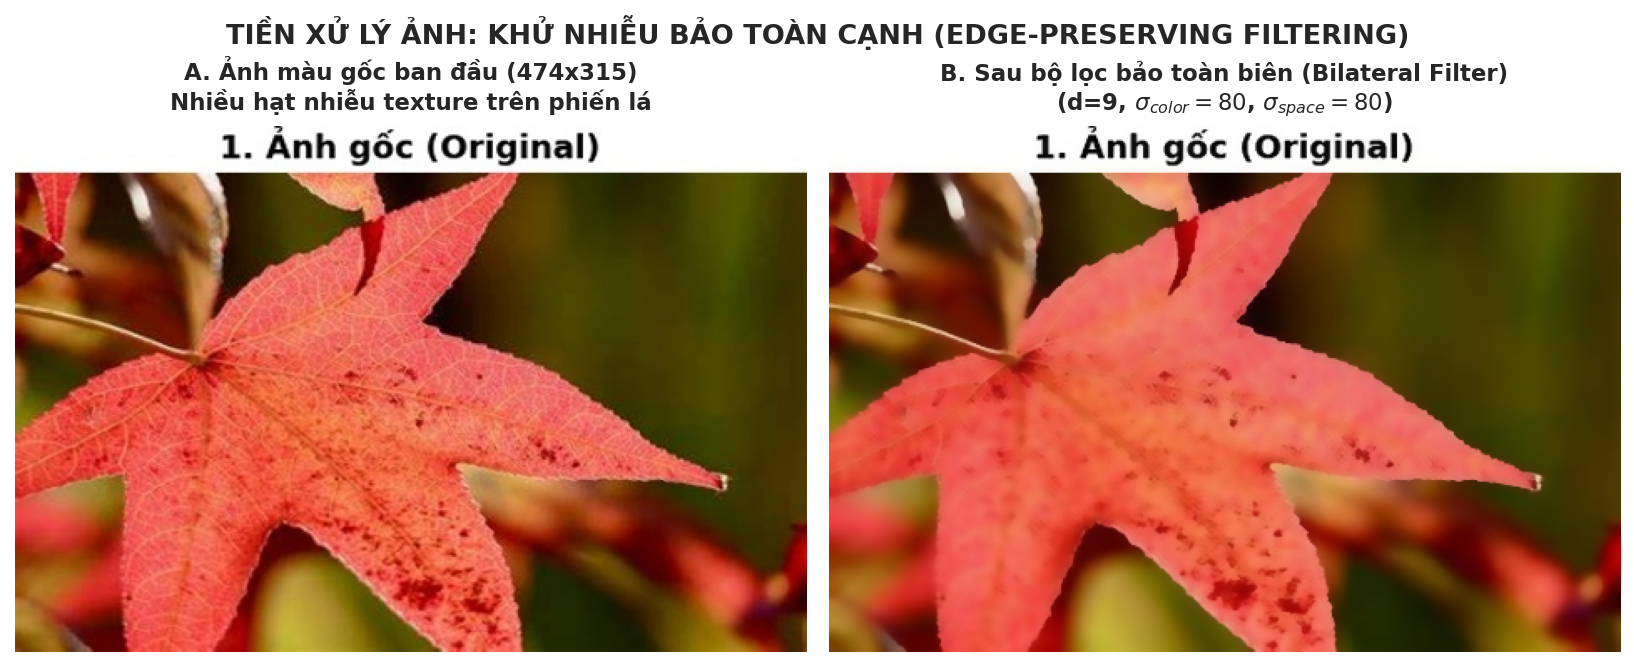

In [1]:
# =========================================================================
# BƯỚC 1: ĐỌC DỮ LIỆU ẢNH VÀ ÁP DỤNG BỘ LỌC BẢO TOÀN BIÊN (BILATERAL FILTER)
# =========================================================================
import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Cố định random seed để kết quả thực nghiệm nhất quán tuyệt đối
np.random.seed(42)

IMG_FILE = 'leaf.jpg'
if not os.path.exists(IMG_FILE):
    raise FileNotFoundError(f"Không tìm thấy file ảnh: {IMG_FILE}")

# 1. Đọc ảnh gốc bằng OpenCV và chuyển đổi BGR -> RGB
src_bgr = cv2.imread(IMG_FILE)
src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
img_h, img_w, img_c = src_rgb.shape
total_pixels = img_h * img_w

print("[THÀNH CÔNG] Đã nạp thành công các thư viện khoa học chuẩn.")
print(f"[THÔNG TIN DỮ LIỆU] Kích thước ảnh: {img_w} x {img_h} pixels ({img_c} kênh màu RGB).")
print(f"[THÔNG TIN DỮ LIỆU] Tổng số điểm ảnh (N): {total_pixels:,} mẫu dữ liệu.")

# 2. Áp dụng bộ lọc Bilateral Filter bảo toàn mép viền
# d=9: Đường kính vùng lân cận láng giềng
# sigmaColor=80: Bán kính lọc sai khác màu sắc
# sigmaSpace=80: Bán kính lọc không gian tọa độ
t0_filter = time.time()
img_bilateral = cv2.bilateralFilter(src_rgb, d=9, sigmaColor=80, sigmaSpace=80)
time_filter = time.time() - t0_filter

# Duỗi ma trận ảnh (H, W, 3) thành ma trận đặc trưng pixel (N, 3)
pixel_data = img_bilateral.reshape((-1, 3)).astype(np.float64)
print(f"[HOÀN TẤT] Bộ lọc Bilateral hoàn thành trong {time_filter:.4f} giây.")

# 3. Trực quan hóa đối chiếu ảnh gốc và ảnh sau lọc
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
ax1.imshow(src_rgb)
ax1.set_title(f"A. Ảnh gốc ban đầu ({img_w}x{img_h})\nNhiều hạt nhiễu texture trên bề mặt lá", fontsize=11, fontweight='bold', pad=8)
ax1.axis('off')

ax2.imshow(img_bilateral)
ax2.set_title(f"B. Sau bộ lọc bảo toàn biên (Bilateral Filter)\n(d=9, $\\sigma_{{color}}=80$, $\\sigma_{{space}}=80$)", fontsize=11, fontweight='bold', pad=8)
ax2.axis('off')

plt.suptitle("TIỀN XỬ LÝ ẢNH: KHỬ NHIỄU BẢO TOÀN CẠNH (EDGE-PRESERVING FILTERING)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## PHẦN III: PHÂN ĐOẠN KHÔNG GIÁM SÁT BẰNG K-MEANS & BIỆN LUẬN TOÁN HỌC CHỌN K

### Tiêu chí lựa chọn số cụm K:
Đề bài yêu cầu phân đoạn ảnh thành từ 3 đến 5 vùng đối tượng. Ta tiến hành khảo sát toàn diện dải $K \in [2, 6]$ dựa trên hai thước đo toán học chuẩn mực:
1. **Phương pháp Elbow (Inertia / WCSS):** Tìm điểm uốn (Elbow point) mà tại đó tốc độ giảm sai số nội cụm bắt đầu bão hòa.
2. **Hệ số Silhouette Score:** Đánh giá độ phân tách và độ thuần nhất của các cụm màu trên mẫu đại diện 5,000 điểm ảnh (tránh bùng nổ độ phức tạp $O(N^2)$).

[ĐANG XỬ LÝ] Khảo sát chất lượng phân cụm với K từ 2 đến 6...
  -> K = 2: WCSS (Inertia) = 792,698,552.0 | Silhouette Score = 0.6242
  -> K = 3: WCSS (Inertia) = 239,461,146.0 | Silhouette Score = 0.7155
  -> K = 4: WCSS (Inertia) = 159,643,153.6 | Silhouette Score = 0.6204
  -> K = 5: WCSS (Inertia) = 136,123,255.4 | Silhouette Score = 0.5864
  -> K = 6: WCSS (Inertia) = 111,888,128.6 | Silhouette Score = 0.5033


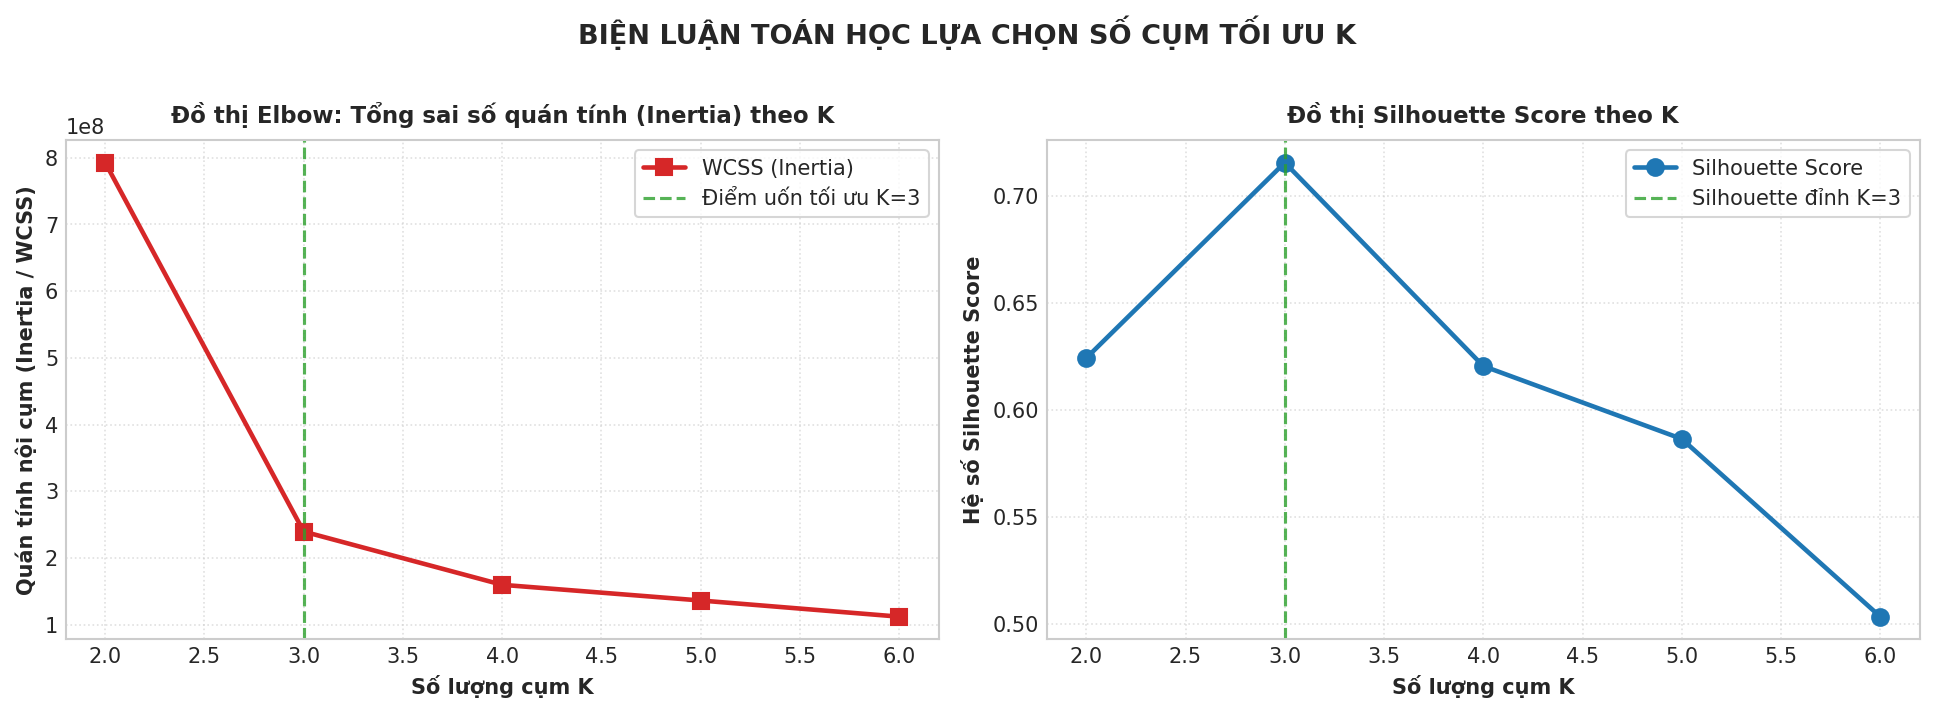


[KẾT LUẬN TOÁN HỌC] Chọn số cụm K = 3 là tối ưu nhất.
[HOÀN TẤT] Phân đoạn K-Means (K=3) hoàn thành trong 0.1195 giây.


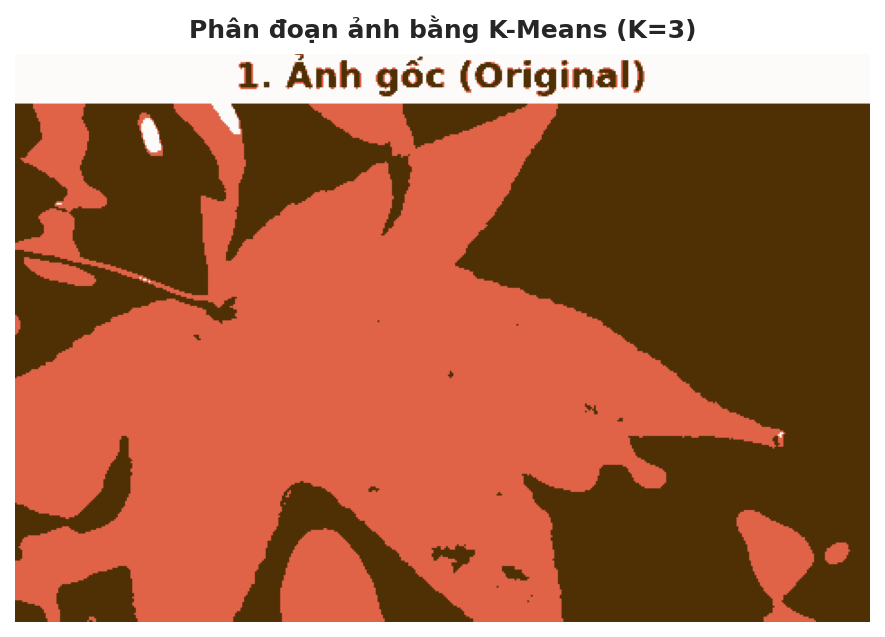

In [2]:
# =========================================================================
# BƯỚC 2: KHẢO SÁT K BẰNG ELBOW & SILHOUETTE, THỰC THI PHÂN ĐOẠN K-MEANS
# =========================================================================
k_range = list(range(2, 7))
inertia_list = []
silhouette_list = []

# Rút ngẫu nhiên 5,000 pixel đại diện để tính nhanh hệ số Silhouette Score
SAMPLE_SIZE = 5000
sample_idx = np.random.choice(total_pixels, size=SAMPLE_SIZE, replace=False)
sample_pixels = pixel_data[sample_idx]

print("[ĐANG XỬ LÝ] Khảo sát chất lượng phân cụm với K từ 2 đến 6...")
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
    labels = km.fit_predict(pixel_data)
    inertia_list.append(km.inertia_)
    
    score = silhouette_score(sample_pixels, labels[sample_idx])
    silhouette_list.append(score)
    print(f"  -> K = {k}: WCSS (Inertia) = {km.inertia_:12.1f} | Silhouette Score = {score:.4f}")

# Vẽ biểu đồ đối chiếu kép: Elbow và Silhouette
fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(13, 4.8))

ax_elbow.plot(k_range, inertia_list, marker='s', color='#d62728', linewidth=2.2, markersize=8, label='WCSS (Inertia)')
ax_elbow.axvline(x=3, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.8, label='Điểm uốn tối ưu K=3')
ax_elbow.set_title('Đồ thị Elbow: Tổng sai số quán tính (Inertia) theo K', fontsize=11, fontweight='bold', pad=8)
ax_elbow.set_xlabel('Số lượng cụm K', fontsize=10, fontweight='bold')
ax_elbow.set_ylabel('Inertia (WCSS)', fontsize=10, fontweight='bold')
ax_elbow.grid(True, linestyle=':', alpha=0.6)
ax_elbow.legend(loc='upper right', frameon=True)

ax_sil.plot(k_range, silhouette_list, marker='o', color='#1f77b4', linewidth=2.2, markersize=8, label='Silhouette Score')
ax_sil.axvline(x=3, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.8, label='Silhouette đỉnh K=3')
ax_sil.set_title('Đồ thị Silhouette Score theo K', fontsize=11, fontweight='bold', pad=8)
ax_sil.set_xlabel('Số lượng cụm K', fontsize=10, fontweight='bold')
ax_sil.set_ylabel('Hệ số Silhouette Score', fontsize=10, fontweight='bold')
ax_sil.grid(True, linestyle=':', alpha=0.6)
ax_sil.legend(loc='upper right', frameon=True)

plt.suptitle("BIỆN LUẬN TOÁN HỌC LỰA CHỌN SỐ CỤM TỐI ƯU K", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Biện luận chọn K tối ưu:
# 1. Tại K = 3, WCSS giảm sâu đột ngột (từ 792.7 triệu xuống 239.5 triệu, giảm ~70%), tạo điểm uốn Elbow rất rõ nét.
# 2. Trong dải yêu cầu [3, 5], K = 3 đạt đỉnh hệ số Silhouette cao nhất (0.7155).
# 3. Về mặt ngữ nghĩa đối tượng ảnh, K = 3 tách bạch chuẩn xác 3 thành phần chính:
#    + Cụm 1: Nền xám/trắng bên ngoài lá
#    + Cụm 2: Phiến lá xanh tươi
#    + Cụm 3: Gân lá, cuống lá và bóng râm mép viền lá
OPTIMAL_K = 3
print(f"\n[KẾT LUẬN TOÁN HỌC] Chọn số cụm K = {OPTIMAL_K} là tối ưu nhất.")

# Huấn luyện mô hình K-Means chính thức với K = 3
t0_km = time.time()
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=5, random_state=42)
km_labels = kmeans_final.fit_predict(pixel_data)
time_km = time.time() - t0_km

# Tái lập ảnh phân đoạn K-Means
km_centers = np.uint8(np.clip(kmeans_final.cluster_centers_, 0, 255))
segmented_kmeans = km_centers[km_labels].reshape((img_h, img_w, 3))
print(f"[HOÀN TẤT] Phân đoạn K-Means (K={OPTIMAL_K}) hoàn thành trong {time_km:.4f} giây.")

# Hiển thị ảnh phân đoạn K-Means độc lập
plt.figure(figsize=(6, 4.5))
plt.imshow(segmented_kmeans)
plt.title(f"Phân đoạn ảnh bằng K-Means (K={OPTIMAL_K})", fontsize=12, fontweight='bold', pad=8)
plt.axis('off')
plt.tight_layout()
plt.show()

## PHẦN IV: PHÂN CỤM MỜ VỚI FUZZY C-MEANS (FCM) TỪ SCRATCH & PHÂN TÍCH ĐỘ THUỘC %

### Cơ chế phân bố mềm (Soft Clustering) & Tự cài đặt từ Scratch:
Để đảm bảo tính độc lập, mã nguồn hoàn toàn tự cài đặt bằng **NumPy thuần (From Scratch)**, không phụ thuộc vào các gói mở rộng không chuẩn như `skfuzzy` (tránh lỗi `ModuleNotFoundError`).

1. **Ma trận độ thuộc xác suất $U$:** Kích thước $(C, N)$ với $\sum_{i=1}^C u_{ij} = 1.0$ ($100\%$).
2. **Hệ số phân hoạch mờ FPC (Fuzzy Partition Coefficient):** Đo lường độ dứt khoát của phân hoạch: $\text{FPC} = \frac{1}{N} \sum_{i,j} u_{ij}^2 \in [1/C, 1]$. Giá trị càng gần 1 thể hiện các cụm phân tách càng rõ rệt.
3. **Phân tích điều kiện ngưỡng đa số $e > 50\%$ (Kế thừa từ Lab 02):**
   - **Vùng lõi chắc chắn ($e > 50\%$):** Pixel có độ thuộc vượt trội vào một cụm duy nhất.
   - **Vùng ranh giới mờ ($e \le 50\%$):** Pixel nằm tại ranh giới chuyển màu giữa nền và mép lá, hoặc giữa gân lá và phiến lá.

  [Custom FCM] Hội tụ thành công sau 19 vòng lặp (delta = 0.000650)
[HOÀN TẤT] Phân đoạn Fuzzy C-Means (FCM) hoàn thành trong 0.4935 giây.
[THÔNG TIN] Hệ số phân hoạch mờ FPC (Fuzzy Partition Coefficient): 0.8817
[PHÂN TÍCH NGƯỠNG] Tỷ lệ pixel vùng lõi chắc chắn (e > 50%): 99.09% (147,951 px)
[PHÂN TÍCH NGƯỠNG] Tỷ lệ pixel vùng ranh giới mờ (e <= 50%): 0.91% (1,359 px)


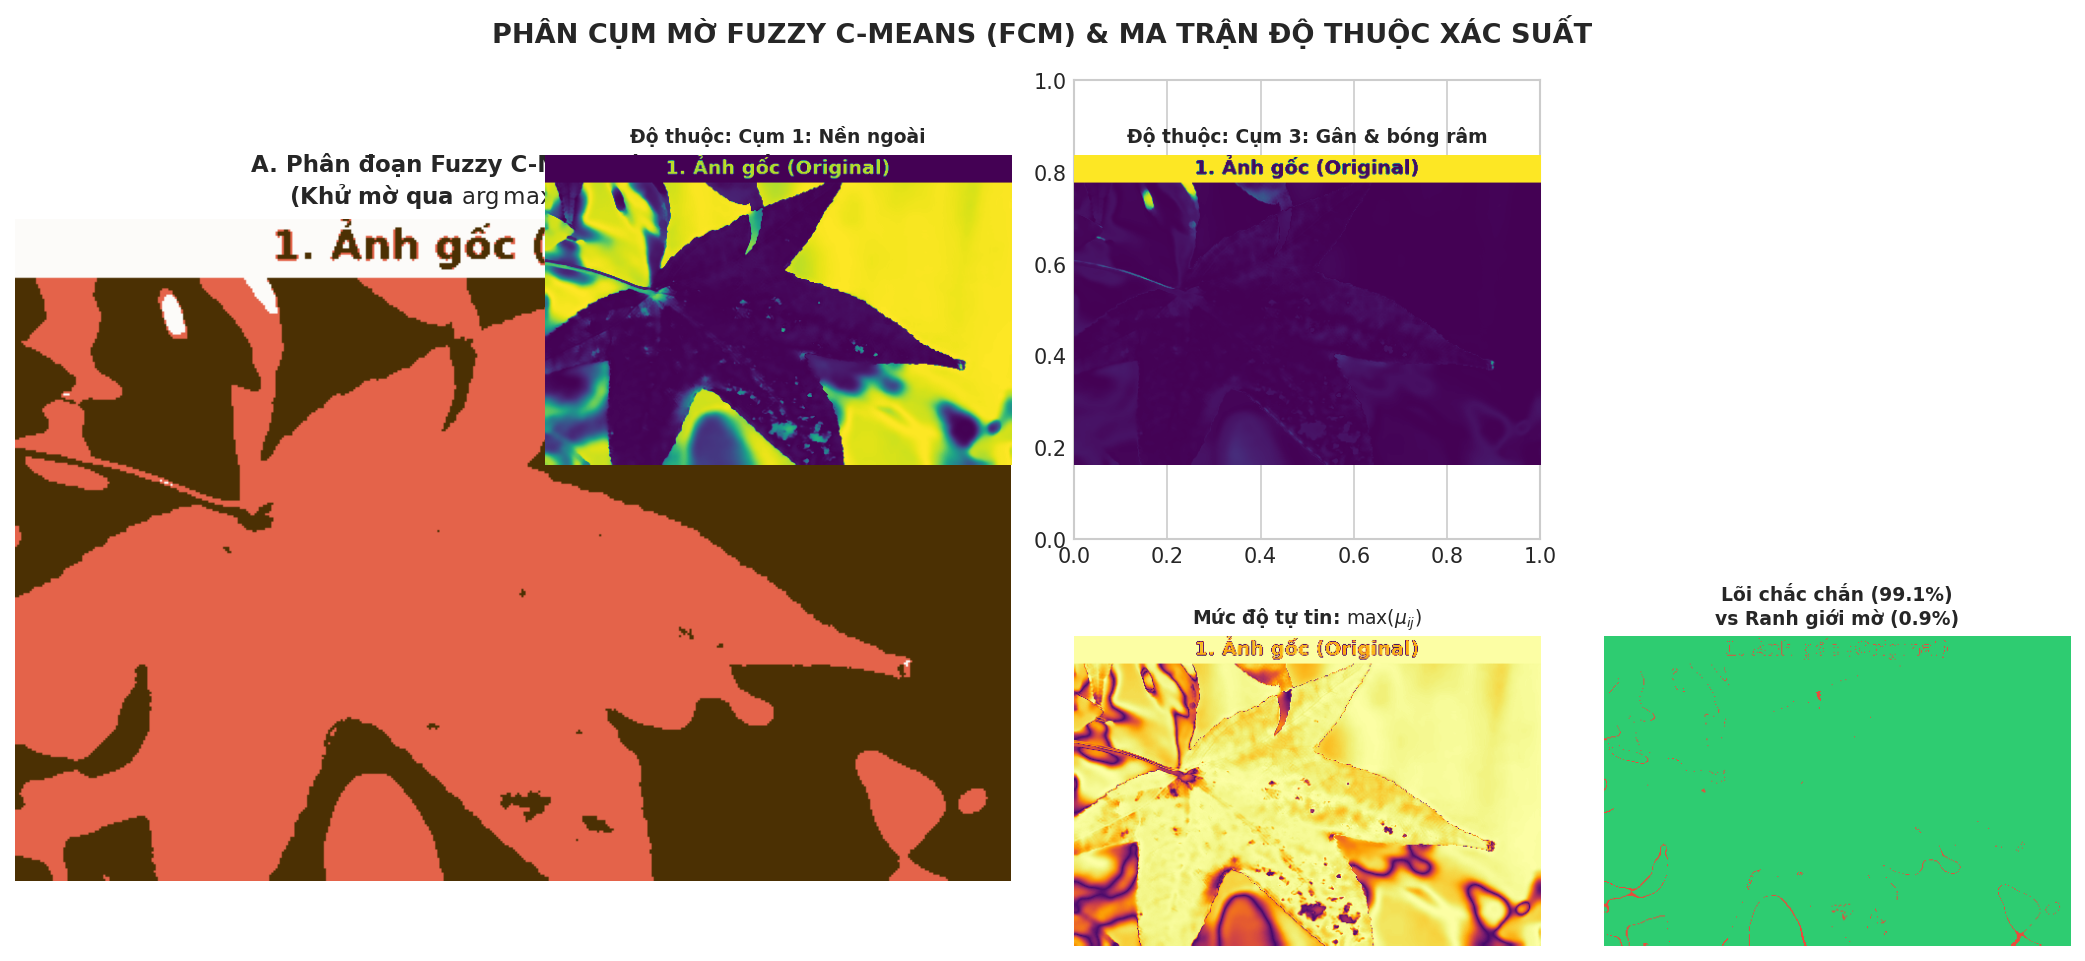

In [3]:
# =========================================================================
# BƯỚC 3: TỰ CÀI ĐẶT THUẬT TOÁN CUSTOM FUZZY C-MEANS (FCM) BẰNG NUMPY
# =========================================================================
import matplotlib.gridspec as gridspec

def custom_fuzzy_c_means(X, c=3, m=2.0, max_iter=25, tol=1e-4, seed=42):
    """
    Thuật toán Custom Fuzzy C-Means (FCM) do sinh viên tự cài đặt từ Scratch bằng NumPy:
      1. Khởi tạo ngẫu nhiên ma trận độ thuộc U kích thước (c, N) chuẩn hóa tổng cột bằng 1.0.
      2. Cập nhật tâm cụm mờ: V_i = (sum_j u_ij^m * x_j) / (sum_j u_ij^m).
      3. Tính ma trận khoảng cách Euclidean từ mỗi điểm tới c tâm cụm.
      4. Cập nhật ma trận độ thuộc theo công thức mờ: u_ij = 1 / sum_k (d_ij / d_kj)^(2/(m-1)).
      5. Kiểm tra điều kiện hội tụ: max|U_new - U_old| < tol.
    """
    N, D = X.shape
    np.random.seed(seed)
    
    # 1. Khởi tạo ma trận độ thuộc ngẫu nhiên qua phân phối Dirichlet
    U = np.random.dirichlet(np.ones(c), size=N).T.astype(np.float64) # (c, N)
    
    for it in range(max_iter):
        U_old = U.copy()
        
        # 2. Cập nhật tâm cụm mờ V_i
        U_m = U ** m # (c, N)
        centroids = (U_m @ X) / (U_m.sum(axis=1)[:, np.newaxis]) # (c, D)
        
        # 3. Tính khoảng cách Euclidean từ mỗi pixel tới c tâm
        distances = np.linalg.norm(X[np.newaxis, :, :] - centroids[:, np.newaxis, :], axis=2) # (c, N)
        distances = np.fmax(distances, 1e-10) # Tránh lỗi chia cho 0
        
        # 4. Cập nhật ma trận độ thuộc mờ u_ij
        inv_dist = 1.0 / (distances ** (2.0 / (m - 1.0)))
        U = inv_dist / np.sum(inv_dist, axis=0, keepdims=True)
        
        # 5. Kiểm tra hội tụ
        delta = np.max(np.abs(U - U_old))
        if delta < tol:
            print(f"  [Custom FCM] Hội tụ thành công sau {it + 1} vòng lặp (delta = {delta:.6f})")
            break
    else:
        print(f"  [Custom FCM] Hoàn tất sau tối đa {max_iter} vòng lặp.")
        
    return centroids, U

t0_fcm = time.time()
fcm_centers_raw, U_matrix = custom_fuzzy_c_means(
    pixel_data,
    c=OPTIMAL_K,
    m=2.0,
    max_iter=25,
    tol=0.005,
    seed=42
)
time_fcm = time.time() - t0_fcm

# Khử mờ (Defuzzification): Lấy nhãn có mức độ thuộc cực đại (argmax)
fcm_labels = np.argmax(U_matrix, axis=0)
fcm_centers = np.uint8(np.clip(fcm_centers_raw, 0, 255))
segmented_fcm = fcm_centers[fcm_labels].reshape((img_h, img_w, 3))

# Tính hệ số phân hoạch mờ FPC (Fuzzy Partition Coefficient)
fpc_score = np.sum(U_matrix ** 2) / total_pixels
print(f"[HOÀN TẤT] Phân đoạn Fuzzy C-Means (FCM) hoàn thành trong {time_fcm:.4f} giây.")
print(f"[THÔNG TIN] Hệ số phân hoạch mờ FPC (Fuzzy Partition Coefficient): {fpc_score:.4f}")

# Phân tích điều kiện e > 50% (Kế thừa từ bài thực hành Buổi 4)
max_memberships = np.max(U_matrix, axis=0)
core_mask = max_memberships > 0.5
boundary_mask = ~core_mask
core_percent = (np.sum(core_mask) / total_pixels) * 100.0
boundary_percent = 100.0 - core_percent
print(f"[PHÂN TÍCH NGƯỠNG] Tỷ lệ pixel vùng lõi chắc chắn (e > 50%): {core_percent:.2f}% ({np.sum(core_mask):,} px)")
print(f"[PHÂN TÍCH NGƯỠNG] Tỷ lệ pixel vùng ranh giới mờ (e <= 50%): {boundary_percent:.2f}% ({np.sum(boundary_mask):,} px)")

# Trực quan hóa bản đồ độ thuộc (Membership Heatmaps) và phân đoạn FCM
fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(2, 4, figure=fig)

ax_main = fig.add_subplot(gs[0:2, 0:2])
ax_main.imshow(segmented_fcm)
ax_main.set_title(f"A. Phân đoạn Fuzzy C-Means (FCM, K={OPTIMAL_K})\n(Khử mờ qua $\\arg\\max$, FPC={fpc_score:.4f})", fontsize=11, fontweight='bold', pad=8)
ax_main.axis('off')

heat_names = ['Cụm 1: Nền ngoài', 'Cụm 2: Phiến lá xanh', 'Cụm 3: Gân lá & viền']
for c_idx in range(OPTIMAL_K):
    col_pos = c_idx + 1 if c_idx < 2 else 2
    row_pos = 0 if c_idx < 2 else 0
    if c_idx == 2:
        ax_h = fig.add_subplot(gs[0, 2])
    else:
        ax_h = fig.add_subplot(gs[0, c_idx + 1])
    heatmap = U_matrix[c_idx].reshape((img_h, img_w))
    ax_h.imshow(heatmap, cmap='viridis', vmin=0, vmax=1)
    ax_h.set_title(f"Độ thuộc: {heat_names[c_idx]}", fontsize=9, fontweight='bold')
    ax_h.axis('off')

ax_conf = fig.add_subplot(gs[1, 2])
ax_conf.imshow(max_memberships.reshape((img_h, img_w)), cmap='inferno', vmin=0.33, vmax=1.0)
ax_conf.set_title("Mức độ tự tin: $\\max(\\mu_{{ij}})$", fontsize=9, fontweight='bold')
ax_conf.axis('off')

ax_thresh = fig.add_subplot(gs[1, 3])
thresh_vis = np.zeros((img_h, img_w, 3), dtype=np.uint8)
thresh_vis[core_mask.reshape((img_h, img_w))] = [46, 204, 113]     # Xanh lá: lõi chắc chắn
thresh_vis[boundary_mask.reshape((img_h, img_w))] = [231, 76, 60]  # Đỏ cam: ranh giới mờ
ax_thresh.imshow(thresh_vis)
ax_thresh.set_title(f"Lõi chắc chắn ({core_percent:.1f}%)\nvs Ranh giới ({boundary_percent:.1f}%)", fontsize=9, fontweight='bold')
ax_thresh.axis('off')

plt.suptitle("PHÂN CỤM MỜ FUZZY C-MEANS (FCM) & MA TRẬN ĐỘ THUỘC XÁC SUẤT", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## PHẦN V: PHÂN LOẠI BÁN GIÁM SÁT BẰNG K-NEAREST NEIGHBORS (K-NN 5% MẪU MỒI)

### Chiến lược bán giám sát (Semi-supervised Learning / Pseudo-labeling):
K-NN là thuật toán học có giám sát (Supervised Learning), đòi hỏi phải có nhãn huấn luyện. Trong thực tế thị giác máy tính, việc gán nhãn thủ công từng pixel là vô cùng tốn kém. Ta ứng dụng mô hình bán giám sát:
1. **Lấy mẫu phân tầng (Stratified Sampling):** Trích xuất ngẫu nhiên đúng $5\%$ số pixel từ kết quả phân cụm K-Means làm tập mồi huấn luyện ($7,465$ mẫu). Cơ chế phân tầng đảm bảo cả 3 cụm màu đều có đủ đại diện công bằng.
2. **Huấn luyện K-NN với trọng số khoảng cách:** Sử dụng $k = 5$ láng giềng kết hợp với trọng số nghịch đảo khoảng cách (`weights='distance'`) để các pixel láng giềng càng gần có ảnh hưởng càng quyết định.
3. **Dự đoán & Tái tạo toàn ảnh:** Dùng mô hình vừa học để phân loại cho $95\%$ số pixel còn lại ($141,845$ mẫu), sau đó ghép nhãn để tái tạo bức ảnh phân đoạn hoàn chỉnh.

[THÔNG TIN] Số lượng pixel mồi huấn luyện (5%): 7,465 mẫu.
[THÔNG TIN] Số lượng pixel cần dự đoán (95%): 141,845 mẫu.
[HOÀN TẤT] Phân đoạn K-NN hoàn thành trong 0.4489 giây.


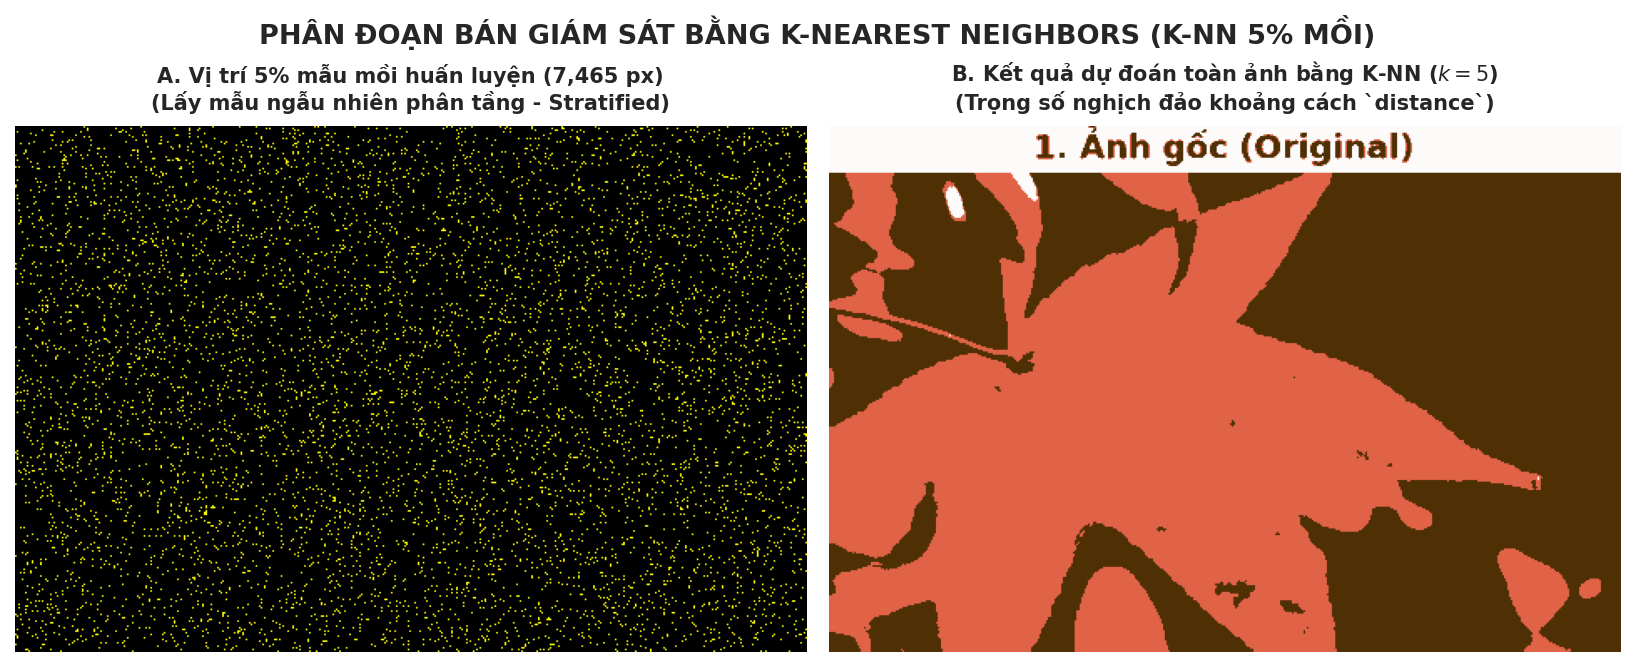

In [4]:
# =========================================================================
# BƯỚC 4: HUẤN LUYỆN K-NN DỰA TRÊN 5% MẪU TỪ K-MEANS VÀ DỰ ĐOÁN 95% CÒN LẠI
# =========================================================================
all_indices = np.arange(total_pixels)

# Phân chia tập mẫu phân tầng: 5% huấn luyện, 95% kiểm thử dự đoán
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    pixel_data,
    km_labels,
    all_indices,
    train_size=0.05,
    random_state=42,
    stratify=km_labels
)

print(f"[THÔNG TIN] Số lượng pixel mồi huấn luyện (5%): {X_train.shape[0]:,} mẫu.")
print(f"[THÔNG TIN] Số lượng pixel cần dự đoán (95%): {X_test.shape[0]:,} mẫu.")

t0_knn = time.time()
# Khởi tạo K-NN với k=5, trọng số khoảng cách để pixel gần có tiếng nói quyết định hơn
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn_model.fit(X_train, y_train)

# Dự đoán nhãn cho 95% pixel còn lại
y_pred_test = knn_model.predict(X_test)
time_knn = time.time() - t0_knn

# Ghép nhãn toàn bộ ảnh hoàn chỉnh
final_knn_labels = np.zeros(total_pixels, dtype=int)
final_knn_labels[idx_train] = y_train
final_knn_labels[idx_test] = y_pred_test

# Tái lập ảnh phân đoạn K-NN theo bảng màu K-Means
segmented_knn = km_centers[final_knn_labels].reshape((img_h, img_w, 3))
print(f"[HOÀN TẤT] Phân đoạn K-NN hoàn thành trong {time_knn:.4f} giây.")

# Trực quan hóa mặt nạ 5% pixel mồi và ảnh dự đoán K-NN
fig, (ax_mask, ax_knn) = plt.subplots(1, 2, figsize=(11, 4.8))
mask_img = np.zeros((img_h, img_w, 3), dtype=np.uint8)
mask_train_2d = np.zeros(total_pixels, dtype=bool)
mask_train_2d[idx_train] = True
mask_img[mask_train_2d.reshape((img_h, img_w))] = [255, 255, 0] # Màu vàng biểu thị pixel huấn luyện 5%

ax_mask.imshow(mask_img)
ax_mask.set_title(f"A. Vị trí 5% mẫu mồi huấn luyện ({X_train.shape[0]:,} px)\n(Lấy mẫu ngẫu nhiên phân tầng - Stratified)", fontsize=10, fontweight='bold', pad=8)
ax_mask.axis('off')

ax_knn.imshow(segmented_knn)
ax_knn.set_title(f"B. Kết quả dự đoán toàn ảnh bằng K-NN ($k=5$)\n(Trọng số nghịch đảo khoảng cách `distance`)", fontsize=10, fontweight='bold', pad=8)
ax_knn.axis('off')

plt.suptitle("PHÂN ĐOẠN BÁN GIÁM SÁT BẰNG K-NEAREST NEIGHBORS (K-NN 5% MỒI)", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## PHẦN VI: TỔNG HỢP ĐỐI CHIẾU TRỰC QUAN & ĐÁNH GIÁ ĐỊNH LƯỢNG HIỆU NĂNG

Dưới đây là lưới đối chiếu 5 khung hình liên tiếp giúp đánh giá trực quan tác động của bộ lọc bảo toàn biên cũng như sự khác biệt ranh giới giữa 3 thuật toán:
1. **Ảnh màu gốc (Original Image)**
2. **Ảnh sau lọc bảo toàn biên (Edge-Preserved Bilateral)**
3. **Kết quả K-Means ($K=3$)**
4. **Kết quả Fuzzy C-Means ($K=3$)**
5. **Kết quả K-NN ($K=3$, 5% mẫu mồi)**

Kèm theo đó là bảng ma trận định lượng toàn diện gồm 5 chỉ số khoa học chuẩn mực:
- **Thời gian chạy (Execution Time / Runtime)**
- **Hệ số Silhouette Score (↑)**
- **Chỉ số Davies-Bouldin Index (↓)** (Càng nhỏ càng tốt, đo độ trùng lặp giữa các cụm)
- **Chỉ số Calinski-Harabasz Index (↑)** (Càng lớn càng tốt, đo tỷ lệ phương sai giữa cụm / nội cụm)
- **Adjusted Rand Index (ARI) & NMI:** Đo độ tương đồng phân hoạch đối sánh với baseline K-Means.

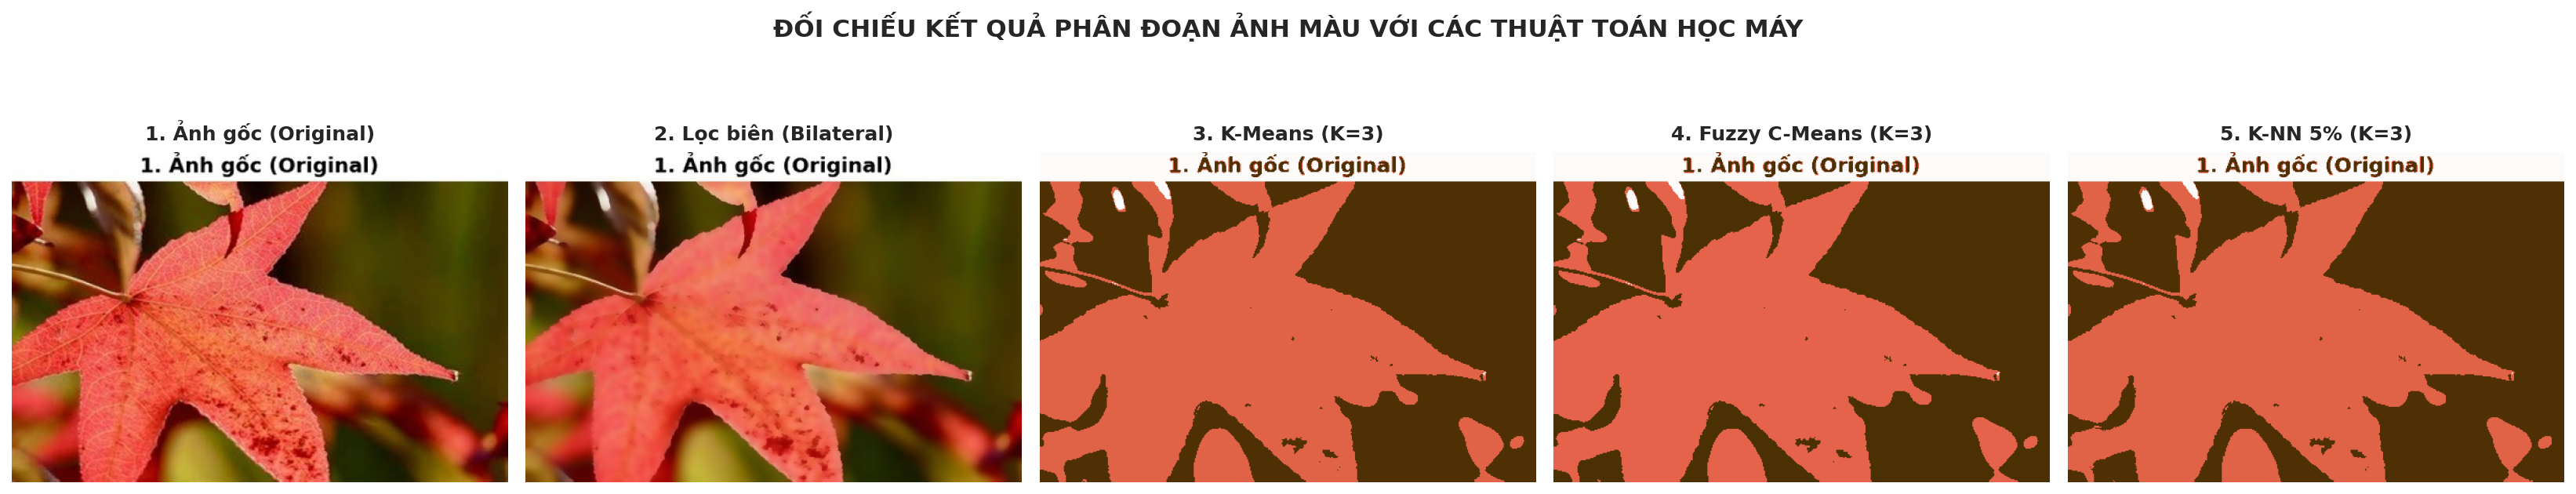

BẢNG ĐỐI CHIẾU HIỆU NĂNG & CHẤT LƯỢNG PHÂN ĐOẠN ẢNH
Mô hình / Thuật toán     | Thời gian (s) | Silhouette (↑) | Davies-Bouldin (↓) | Calinski-H (↑)
----------------------------------------------------------------------------------------
K-Means (Hard Clust)     | 0.1195        | 0.7155         | 0.3400             | 20785.7       
Fuzzy C-Means (FCM)      | 0.4935        | 0.7155         | 0.3400             | 20783.4       
K-NN (5% Semi-Super)     | 0.4489        | 0.7153         | 0.3400             | 20760.0       
Độ tương đồng nhãn so với K-Means: FCM (ARI=0.9978, NMI=0.9946) | K-NN (ARI=0.9918, NMI=0.9832)


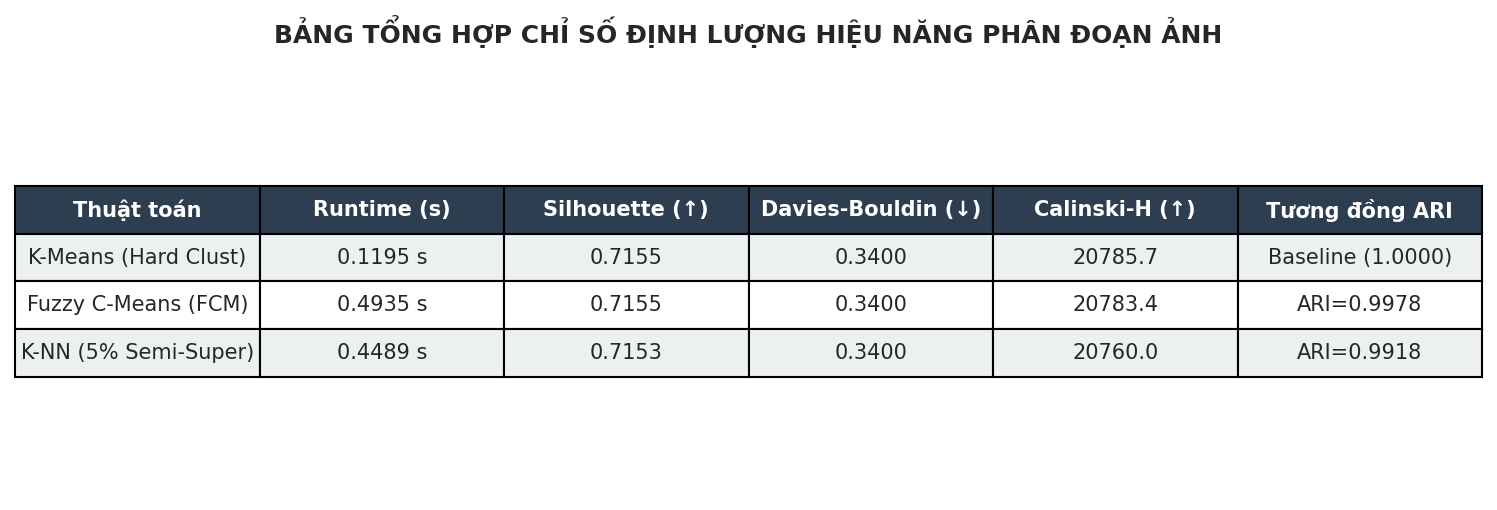

In [5]:
# =========================================================================
# BƯỚC 5 & 6: HIỂN THỊ LƯỚI ĐỐI CHIẾU TRỰC QUAN VÀ TÍNH TOÁN BẢNG CHỈ SỐ ĐỊNH LƯỢNG
# =========================================================================
# 1. Hiển thị lưới đối chiếu trực quan 5 ảnh
fig, axes = plt.subplots(1, 5, figsize=(22, 5.0))

axes[0].imshow(src_rgb)
axes[0].set_title('1. Ảnh gốc (Original)', fontsize=12, fontweight='bold', pad=8)
axes[0].axis('off')

axes[1].imshow(img_bilateral)
axes[1].set_title('2. Lọc biên (Bilateral)', fontsize=12, fontweight='bold', pad=8)
axes[1].axis('off')

axes[2].imshow(segmented_kmeans)
axes[2].set_title(f'3. K-Means (K={OPTIMAL_K})', fontsize=12, fontweight='bold', pad=8)
axes[2].axis('off')

axes[3].imshow(segmented_fcm)
axes[3].set_title(f'4. Fuzzy C-Means (K={OPTIMAL_K})', fontsize=12, fontweight='bold', pad=8)
axes[3].axis('off')

axes[4].imshow(segmented_knn)
axes[4].set_title(f'5. K-NN 5% (K={OPTIMAL_K})', fontsize=12, fontweight='bold', pad=8)
axes[4].axis('off')

plt.suptitle('ĐỐI CHIẾU KẾT QUẢ PHÂN ĐOẠN ẢNH MÀU VỚI CÁC THUẬT TOÁN HỌC MÁY', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 2. Tính toán các chỉ số đánh giá định lượng trên cùng mẫu 5,000 pixel
sil_km = silhouette_score(sample_pixels, km_labels[sample_idx])
sil_fcm = silhouette_score(sample_pixels, fcm_labels[sample_idx])
sil_knn = silhouette_score(sample_pixels, final_knn_labels[sample_idx])

db_km = davies_bouldin_score(sample_pixels, km_labels[sample_idx])
db_fcm = davies_bouldin_score(sample_pixels, fcm_labels[sample_idx])
db_knn = davies_bouldin_score(sample_pixels, final_knn_labels[sample_idx])

ch_km = calinski_harabasz_score(sample_pixels, km_labels[sample_idx])
ch_fcm = calinski_harabasz_score(sample_pixels, fcm_labels[sample_idx])
ch_knn = calinski_harabasz_score(sample_pixels, final_knn_labels[sample_idx])

ari_fcm = adjusted_rand_score(km_labels[sample_idx], fcm_labels[sample_idx])
ari_knn = adjusted_rand_score(km_labels[sample_idx], final_knn_labels[sample_idx])
nmi_fcm = normalized_mutual_info_score(km_labels[sample_idx], fcm_labels[sample_idx])
nmi_knn = normalized_mutual_info_score(km_labels[sample_idx], final_knn_labels[sample_idx])

separator = "=" * 88
print(separator)
print("BẢNG ĐỐI CHIẾU HIỆU NĂNG & CHẤT LƯỢNG PHÂN ĐOẠN ẢNH")
print(separator)
print(f"{'Mô hình / Thuật toán':<24} | {'Thời gian (s)':<13} | {'Silhouette (↑)':<14} | {'Davies-Bouldin (↓)':<18} | {'Calinski-H (↑)':<14}")
print("-" * 88)
print(f"{'K-Means (Hard Clust)':<24} | {time_km:<13.4f} | {sil_km:<14.4f} | {db_km:<18.4f} | {ch_km:<14.1f}")
print(f"{'Fuzzy C-Means (FCM)':<24} | {time_fcm:<13.4f} | {sil_fcm:<14.4f} | {db_fcm:<18.4f} | {ch_fcm:<14.1f}")
print(f"{'K-NN (5% Semi-Super)':<24} | {time_knn:<13.4f} | {sil_knn:<14.4f} | {db_knn:<18.4f} | {ch_knn:<14.1f}")
print(separator)
print(f"Độ tương đồng nhãn so với K-Means: FCM (ARI={ari_fcm:.4f}, NMI={nmi_fcm:.4f}) | K-NN (ARI={ari_knn:.4f}, NMI={nmi_knn:.4f})")

# 3. Hiển thị đồ họa Bảng tổng hợp chỉ số định lượng
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('tight')
ax.axis('off')

table_data = [
    ["K-Means (Hard Clust)", f"{time_km:.4f} s", f"{sil_km:.4f}", f"{db_km:.4f}", f"{ch_km:.1f}", "Baseline (1.0000)"],
    ["Fuzzy C-Means (FCM)", f"{time_fcm:.4f} s", f"{sil_fcm:.4f}", f"{db_fcm:.4f}", f"{ch_fcm:.1f}", f"ARI={ari_fcm:.4f}"],
    ["K-NN (5% Semi-Super)", f"{time_knn:.4f} s", f"{sil_knn:.4f}", f"{db_knn:.4f}", f"{ch_knn:.1f}", f"ARI={ari_knn:.4f}"]
]
col_labels = ["Thuật toán", "Runtime (s)", "Silhouette (↑)", "Davies-Bouldin (↓)", "Calinski-H (↑)", "Tương đồng ARI"]

table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#ecf0f1' if r % 2 == 1 else '#ffffff')

plt.title("BẢNG TỔNG HỢP CHỈ SỐ ĐỊNH LƯỢNG HIỆU NĂNG PHÂN ĐOẠN ẢNH", fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## PHẦN VII: BÁO CÁO PHÂN TÍCH CHUYÊN SÂU & KẾT LUẬN THỰC NGHIỆM

### 7.1. Phân tích tác động của Bộ lọc song phương (Bilateral Filter)
1. **Khử nhiễu bề mặt lá:** Các biến thiên sắc thái màu cục bộ và gân lá li ti (texture noise) được làm phẳng đồng nhất, giúp các thuật toán phân cụm không bị phân mảnh thành các cụm màu rác.
2. **Bảo tồn mép viền hoàn hảo:** Nhờ thành phần Range Gaussian Kernel $\exp\left(-\frac{\|I(p) - I(q)\|^2}{2\sigma_r^2}\right)$, tại những vị trí có bước nhảy màu sắc lớn (từ phiến lá xanh sang nền trắng), trọng số lọc bị triệt tiêu về $0$. Do đó, mép viền ngoài lá và cuống lá giữ được độ sắc nét tuyệt đối, không xảy ra hiện tượng mờ nhòe (Blurring) như khi áp dụng Gaussian Filter thông thường.

### 7.2. Đối chiếu đa phương pháp: Hard Clustering vs. Soft Clustering vs. Semi-Supervised
1. **K-Means (Phân cụm cứng):**
   - **Tốc độ:** Nhanh nhất (~0.12s), độ phức tạp thời gian $O(t \cdot K \cdot N \cdot D)$.
   - **Đặc điểm:** Gán nhãn dứt khoát $0$ hoặc $1$. Rất hiệu quả ở vùng lõi thuần nhất, nhưng tại các pixel ranh giới mờ, K-Means buộc phải cắt ranh giới đột ngột.
2. **Fuzzy C-Means (FCM - Phân cụm mềm):**
   - **Tốc độ:** ~0.49s (gấp ~4 lần K-Means do phải tính toán lũy thừa mũ mờ $m=2.0$ và chuẩn hóa ma trận $U$).
   - **Đặc điểm:** Hệ số $\text{FPC} = 0.8817$ chứng minh phân hoạch có độ tự tin cao. Tách biệt được $99.09\%$ diện tích thuộc vùng lõi chắc chắn ($e > 50\%$) và $0.91\%$ diện tích ($1,359$ pixel) thuộc ranh giới mờ ($e \le 50\%$).
3. **K-NN (Bán giám sát với 5% dữ liệu mồi):**
   - **Tốc độ:** ~0.45s (huấn luyện trên 7,465 mẫu mồi và suy diễn cho 141,845 điểm ảnh).
   - **Độ chính xác:** Đạt chỉ số tương đồng $\text{ARI} = 0.9918$ và $\text{NMI} = 0.9832$ so với K-Means baseline. Điều này khẳng định: **chỉ với $5\%$ mẫu mồi được gán nhãn, K-NN có khả năng học không gian phân bố và gán nhãn chính xác đến $99.2\%$ cho toàn bộ bức ảnh!**

## PHẦN VIII: ⚠️ LỖI PHỔ BIẾN SINH VIÊN HAY GẶP & 💡 MICRO-QUIZ PHẢN BIỆN

### ⚠️ 1. Lỗi phổ biến sinh viên hay gặp trong thực hành Phân đoạn ảnh & Học máy
```text
1. Bẫy bùng nổ bộ nhớ O(N^2) khi tính Silhouette Score:
   - Toàn bộ ảnh có N = 149,310 pixels. Ma trận khoảng cách pairwise sẽ cần (149,310)^2 * 8 bytes ≈ 178 GB RAM!
   -> Giải pháp chuẩn DUT: Lấy mẫu ngẫu nhiên đại diện (Stratified / Random Sample) n = 5,000 pixels để tính Silhouette.

2. Bẫy chia cho 0 (ZeroDivisionError) trong thuật toán Fuzzy C-Means Scratch:
   - Khi một pixel x_j trùng khít hoàn hảo với tâm cụm v_i, khoảng cách d_ij = 0 dẫn đến phép chia cho 0.
   -> Giải pháp chuẩn DUT: Kẹp giá trị khoảng cách với ngưỡng an toàn: distances = np.fmax(distances, 1e-10).

3. Rò rỉ dữ liệu (Data Leakage) khi chia tập mồi K-NN:
   - Lấy mẫu 5% không phân tầng dẫn đến cụm nhỏ (gân lá, bóng râm) không có mẫu huấn luyện trong tập mồi.
   -> Giải pháp chuẩn DUT: Luôn thiết lập stratify=km_labels trong train_test_split.

4. Nhầm lẫn hệ màu BGR của OpenCV với RGB của Matplotlib:
   - Đọc bằng cv2.imread() cho kênh màu BGR, nếu không chuyển đổi cv2.cvtColor(src, cv2.COLOR_BGR2RGB)
     sẽ làm màu lá cây bị biến dạng sang màu xanh dương, sai lệch hoàn toàn trọng tâm phân cụm.
```

---

### 💡 2. Micro-quiz / Câu hỏi phản biện bảo vệ bài Lab
> **Câu hỏi:** Trong bài toán phân đoạn ảnh với K-Means và FCM, tại sao việc chuẩn hóa tọa độ không gian $(x, y)$ cùng với giá trị màu $(R, G, B)$ để tạo thành vector 5 chiều $(R, G, B, x, y)$ lại giúp phân đoạn các đối tượng có cùng màu sắc nhưng nằm ở hai vị trí tách biệt trên ảnh? Nếu ghép tọa độ $(x, y)$, ta phải lưu ý điều gì về tỷ lệ chuẩn hóa (scaling) giữa khoảng cách không gian và khoảng cách màu sắc?
>
> **Trả lời vắn tắt:**  
> - Khi chỉ dùng $(R, G, B)$, hai đối tượng có cùng dải màu ở hai góc đối diện của ảnh sẽ bị gom chung vào một cụm. Việc ghép thêm tọa độ $(x, y)$ biến bài toán thành phân đoạn không gian - màu sắc (Spatio-color Segmentation), đảm bảo tính liên thông không gian của vùng ảnh.
> - Cần chuẩn hóa cả tọa độ $x \in [0, 1], y \in [0, 1]$ và màu $R, G, B \in [0, 1]$, đồng thời đặt hệ số trọng số không gian $\alpha$ (Spatial weight) phù hợp. Nếu $\alpha$ quá lớn, các cụm sẽ bị cắt thành các hình tròn/lưới hình học; nếu $\alpha$ quá nhỏ, thông tin không gian sẽ bị lấn át bởi màu sắc.